# Separación de background y perturbación en datos sintéticos

Este notebook:

- carga `synthetic_F3_nexp_seed_fine2.h5`
- usa `A_syn`, `phi_syn`, `A_bg` y `phi_bg`
- ajusta **F3 + background polinómico** de grados **3, 4, 5, 6, 7, 8 y 9**
- separa explícitamente:
  - `background true`
  - `background ajustado`
  - `perturbación true = señal total - background true`
  - `perturbación ajustada`
- compara los modelos usando:
  - métricas del ajuste total (`redchi`, `AIC`, `BIC`, `R²`)
  - métricas contra la verdad (`RMSE`, `MAE`, `bias`, `R²`) para background y perturbación

La lógica del ajuste se aplica tanto a **amplitud** como a **fase**.


Datasets disponibles: ['A_bg', 'A_syn', 'coeffs_beta_alb', 'coeffs_h_alb', 'pars_syn', 'phi_bg', 'phi_syn', 'target_A_corr', 'target_A_raw', 'target_phi_corr', 'target_phi_raw', 'timestamps']
Atributos disponibles: ['model', 'note']

model = F3_gaussiana_asimetrica_nexp_vertical
note  = Serie sintética perturbada y serie background generadas con el mismo background ionosférico del script real

Grados de background evaluados: (3, 4, 5, 6, 7)

Tamaños:
  timestamps => 241
  A_bg       => 241
  phi_bg     => 241
  A_syn      => 241
  phi_syn    => 241
  target_A_raw    => 241
  target_A_corr   => 241
  target_phi_raw  => 241
  target_phi_corr => 241
  pars_syn        => 7
  coeffs_h_alb    => 9
  coeffs_beta_alb => 6

Primeras 3 marcas de tiempo UTC:
DatetimeIndex(['2008-03-25 18:00:00', '2008-03-25 18:01:00',
               '2008-03-25 18:02:00'],
              dtype='datetime64[ns]', freq=None)

=== RESUMEN AMPLITUD ===
   canal  grado_bg   redchi          aic          bic       r2  nfe

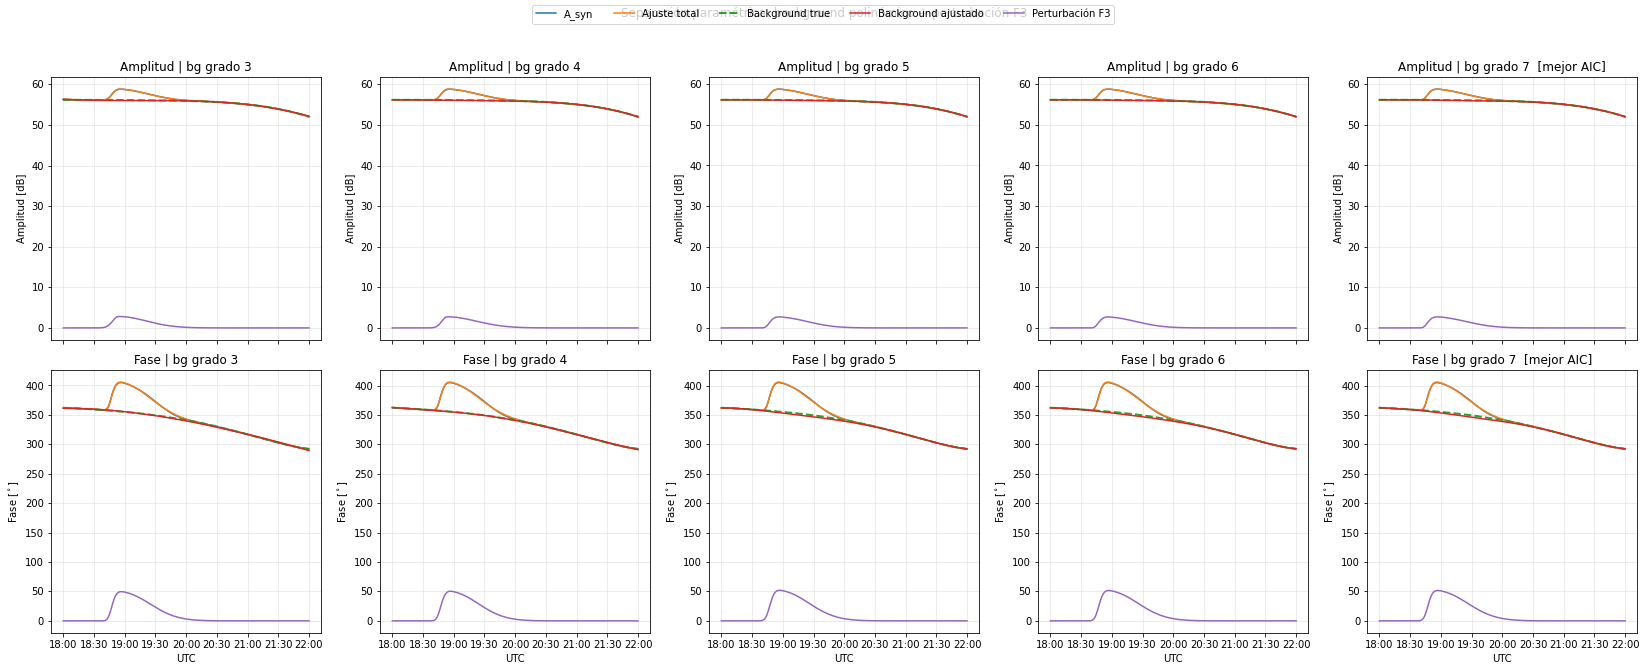

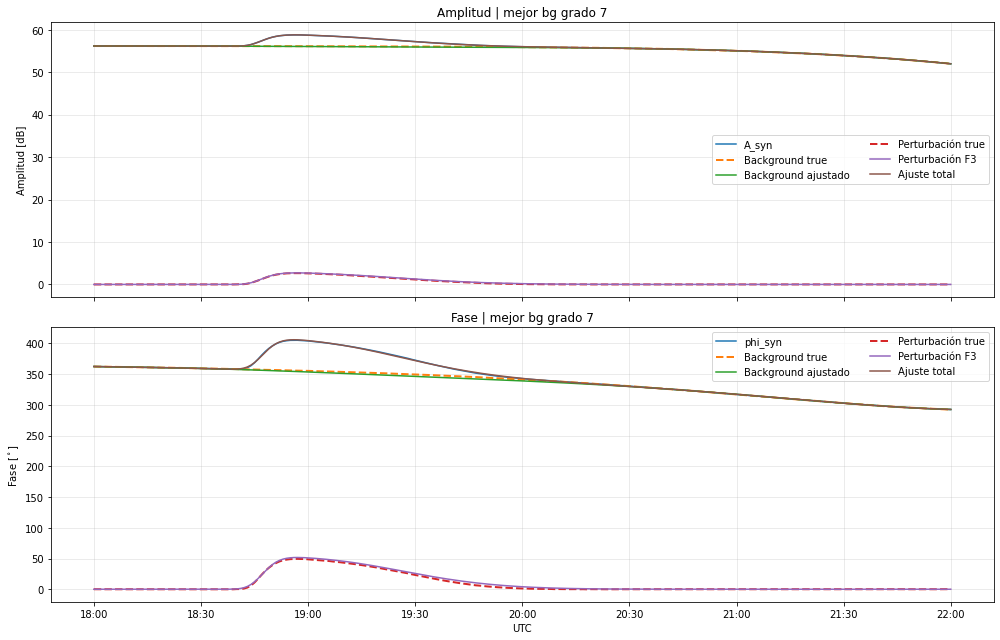

In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from lmfit import Model, Parameters

# ============================================================
# CONFIG
# ============================================================
filename = "synthetic_F3_nexp_seed_fine2.h5"
assert os.path.isfile(filename), f"No existe el archivo: {filename}"

#BG_DEGREES = (3, 4, 5, 6, 7, 8, 9)
BG_DEGREES = (3, 4, 5, 6, 7)

# ============================================================
# CARGA DEL H5
# ============================================================
def _decode_if_needed(x):
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")
    if isinstance(x, np.ndarray) and x.shape == () and isinstance(x.item(), bytes):
        return x.item().decode("utf-8", errors="replace")
    return x

with h5py.File(filename, "r") as f:
    data = {k: f[k][()] for k in f.keys()}
    attrs = {k: _decode_if_needed(v) for k, v in f.attrs.items()}

required = ["timestamps", "A_bg", "phi_bg", "A_syn", "phi_syn"]
missing = [k for k in required if k not in data]
assert not missing, f"Faltan datasets obligatorios en el archivo: {missing}"

timestamps = np.asarray(data["timestamps"], dtype=float)
A_bg       = np.asarray(data["A_bg"], dtype=float)
phi_bg     = np.asarray(data["phi_bg"], dtype=float)
A_syn      = np.asarray(data["A_syn"], dtype=float)
phi_syn    = np.asarray(data["phi_syn"], dtype=float)

# si existen en el archivo, también los dejamos disponibles
target_A_raw    = np.asarray(data["target_A_raw"], dtype=float) if "target_A_raw" in data else None
target_A_corr   = np.asarray(data["target_A_corr"], dtype=float) if "target_A_corr" in data else None
target_phi_raw  = np.asarray(data["target_phi_raw"], dtype=float) if "target_phi_raw" in data else None
target_phi_corr = np.asarray(data["target_phi_corr"], dtype=float) if "target_phi_corr" in data else None

pars_syn         = np.asarray(data["pars_syn"], dtype=float) if "pars_syn" in data else None
coeffs_h_alb     = np.asarray(data["coeffs_h_alb"], dtype=float) if "coeffs_h_alb" in data else None
coeffs_beta_alb  = np.asarray(data["coeffs_beta_alb"], dtype=float) if "coeffs_beta_alb" in data else None

time_utc = pd.to_datetime(timestamps, unit="s", utc=True).tz_convert("UTC").tz_localize(None)

A_pert_true   = A_syn - A_bg
phi_pert_true = phi_syn - phi_bg

model_attr = attrs.get("model", "")
note_attr  = attrs.get("note", "")

print("Datasets disponibles:", sorted(data.keys()))
print("Atributos disponibles:", sorted(attrs.keys()))
print("\nmodel =", model_attr)
print("note  =", note_attr)
print("\nGrados de background evaluados:", BG_DEGREES)

print("\nTamaños:")
print("  timestamps =>", len(timestamps))
print("  A_bg       =>", len(A_bg))
print("  phi_bg     =>", len(phi_bg))
print("  A_syn      =>", len(A_syn))
print("  phi_syn    =>", len(phi_syn))
if target_A_raw is not None:
    print("  target_A_raw    =>", len(target_A_raw))
if target_A_corr is not None:
    print("  target_A_corr   =>", len(target_A_corr))
if target_phi_raw is not None:
    print("  target_phi_raw  =>", len(target_phi_raw))
if target_phi_corr is not None:
    print("  target_phi_corr =>", len(target_phi_corr))
if pars_syn is not None:
    print("  pars_syn        =>", len(pars_syn))
if coeffs_h_alb is not None:
    print("  coeffs_h_alb    =>", len(coeffs_h_alb))
if coeffs_beta_alb is not None:
    print("  coeffs_beta_alb =>", len(coeffs_beta_alb))

print("\nPrimeras 3 marcas de tiempo UTC:")
print(time_utc[:3])

# ============================================================
# HELPERS
# ============================================================
def poly_bg(t, coeffs):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t, dtype=float)
    for i, c in enumerate(coeffs):
        out += c * t**i
    return out

def delta_form3(t, t_pk, amp, tau_u, tau_d, eps):
    tau_u = max(float(tau_u), 1e-9)
    tau_d = max(float(tau_d), 1e-9)
    eps   = max(float(eps),   1e-9)

    tt = np.asarray(t, dtype=float)
    w = tau_u + 0.5 * (tau_d - tau_u) * (1.0 + np.tanh((tt - t_pk) / eps))
    w = np.maximum(w, 1e-9)
    return amp * np.exp(-0.5 * ((tt - t_pk) / w)**2)

def build_f3_model(deg):
    coeff_names = [f"a{i}" for i in range(deg + 1)]
    arg_list = ", ".join(["t"] + coeff_names + ["amp", "t_pk", "tau_u", "tau_d", "eps"])

    coeff_expr = ", ".join(coeff_names)
    body = (
        f"def f3_deg{deg}({arg_list}):\n"
        f"    return poly_bg(t, [{coeff_expr}]) + delta_form3(t, t_pk, amp, tau_u, tau_d, eps)"
    )
    namespace = {"poly_bg": poly_bg, "delta_form3": delta_form3}
    exec(body, namespace)
    fn = namespace[f"f3_deg{deg}"]
    return Model(fn)

MODEL_BY_DEG = {deg: build_f3_model(deg) for deg in BG_DEGREES}

def init_poly_coeffs(deg, t_fit, y_fit):
    n = len(t_fit)
    edge_n = max(8, n // 10)
    edge_n = min(edge_n, max(8, n // 2))

    t_edge = np.r_[t_fit[:edge_n], t_fit[-edge_n:]]
    y_edge = np.r_[y_fit[:edge_n], y_fit[-edge_n:]]
    p = np.polyfit(t_edge, y_edge, deg)   # [a_deg, ..., a0]
    return p[::-1]                        # [a0, a1, ..., a_deg]

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rss = np.sum((y_true - y_pred)**2)
    tss = np.sum((y_true - np.mean(y_true))**2)
    return np.nan if tss <= 0 else 1.0 - rss / tss

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(y_pred - y_true)

def build_params_for_f3(deg, t_fit, y_fit):
    coeffs0 = init_poly_coeffs(deg, t_fit, y_fit)
    bg0 = poly_bg(t_fit, coeffs0)
    resid0 = y_fit - bg0

    # semilla del pico = mayor desvío absoluto respecto a un background preliminar
    i0 = int(np.argmax(np.abs(resid0)))
    t_pk0 = float(t_fit[i0])
    amp0  = float(resid0[i0])

    dt_step = float(np.median(np.diff(t_fit))) if len(t_fit) > 1 else 1.0
    t_span  = float(t_fit.max() - t_fit.min()) if len(t_fit) > 1 else 1.0
    y_range = float(np.ptp(y_fit))
    amp_ref = max(abs(amp0), y_range, 1.0)

    pars = Parameters()
    for i, c in enumerate(coeffs0):
        pars.add(f"a{i}", value=float(c))

    # amp libre de signo: sirve para amplitud y fase
    pars.add("amp",   value=amp0, min=-10.0 * amp_ref, max=10.0 * amp_ref)
    pars.add("t_pk",  value=t_pk0, min=float(t_fit.min()), max=float(t_fit.max()))
    pars.add("tau_u", value=max(3.0 * dt_step, 0.03 * t_span),
             min=max(dt_step / 10.0, 1e-6), max=max(2.0 * t_span, dt_step))
    pars.add("tau_d", value=max(6.0 * dt_step, 0.06 * t_span),
             min=max(dt_step / 10.0, 1e-6), max=max(2.0 * t_span, dt_step))
    pars.add("eps",   value=max(2.0 * dt_step, 0.02 * t_span),
             min=max(dt_step / 10.0, 1e-6), max=max(t_span, dt_step))
    return pars

def fit_channel(y_fit, time_utc, channel_name, degrees=BG_DEGREES, max_nfev=30000):
    y_fit = np.asarray(y_fit, dtype=float)
    t_fit = (time_utc - time_utc[0]).total_seconds().to_numpy() / 3600.0

    fit_results = {}
    separated = {}
    rows = []
    max_deg = max(degrees)

    for deg in degrees:
        mdl = MODEL_BY_DEG[deg]
        pars = build_params_for_f3(deg, t_fit, y_fit)
        res = mdl.fit(y_fit, pars, t=t_fit, nan_policy="omit", max_nfev=max_nfev)

        coeffs = [res.params[f"a{i}"].value for i in range(deg + 1)]
        amp    = res.params["amp"].value
        t_pk   = res.params["t_pk"].value
        tau_u  = res.params["tau_u"].value
        tau_d  = res.params["tau_d"].value
        eps    = res.params["eps"].value

        bg_fit    = poly_bg(t_fit, coeffs)
        delta_fit = delta_form3(t_fit, t_pk, amp, tau_u, tau_d, eps)
        total_fit = bg_fit + delta_fit
        resid_fit = y_fit - total_fit

        fit_results[deg] = res
        separated[deg] = {
            "t_hours": t_fit.copy(),
            "time_utc": time_utc.copy(),
            "data": y_fit.copy(),
            "background": bg_fit,
            "perturbation": delta_fit,
            "total_fit": total_fit,
            "residual": resid_fit,
            "params": {
                **{f"a{i}": coeffs[i] for i in range(deg + 1)},
                "amp": amp,
                "t_pk": t_pk,
                "tau_u": tau_u,
                "tau_d": tau_d,
                "eps": eps,
            },
        }

        row = {
            "canal": channel_name,
            "grado_bg": deg,
            "redchi": res.redchi,
            "aic": res.aic,
            "bic": res.bic,
            "r2": r2_score(y_fit, total_fit),
            "nfev": getattr(res, "nfev", np.nan),
            "amp": amp,
            "t_pk_h": t_pk,
            "tau_u_h": tau_u,
            "tau_d_h": tau_d,
            "eps_h": eps,
        }
        for i in range(max_deg + 1):
            row[f"a{i}"] = coeffs[i] if i < len(coeffs) else np.nan
        rows.append(row)

    summary = pd.DataFrame(rows).sort_values(["aic", "bic", "redchi"]).reset_index(drop=True)
    best_deg = int(summary.iloc[0]["grado_bg"])
    return {
        "fit_results": fit_results,
        "separated": separated,
        "summary": summary,
        "best_deg": best_deg,
    }

def compare_against_truth(fit_dict, y_true_bg, y_true_pert, channel_name):
    rows = []
    for deg, s in fit_dict["separated"].items():
        bg_fit = s["background"]
        pert_fit = s["perturbation"]
        total_fit = s["total_fit"]

        rows.append({
            "canal": channel_name,
            "grado_bg": deg,
            "rmse_bg": rmse(y_true_bg, bg_fit),
            "mae_bg": mae(y_true_bg, bg_fit),
            "bias_bg": bias(y_true_bg, bg_fit),
            "r2_bg": r2_score(y_true_bg, bg_fit),
            "rmse_pert": rmse(y_true_pert, pert_fit),
            "mae_pert": mae(y_true_pert, pert_fit),
            "bias_pert": bias(y_true_pert, pert_fit),
            "r2_pert": r2_score(y_true_pert, pert_fit),
            "rmse_total_vs_data": rmse(s["data"], total_fit),
            "mae_total_vs_data": mae(s["data"], total_fit),
        })

    return pd.DataFrame(rows).sort_values("grado_bg").reset_index(drop=True)

# ============================================================
# AJUSTES
# ============================================================
fit_A   = fit_channel(A_syn,   time_utc, "Amplitud")
fit_phi = fit_channel(phi_syn, time_utc, "Fase")

summary_all = pd.concat([fit_A["summary"], fit_phi["summary"]], ignore_index=True)

print("\n=== RESUMEN AMPLITUD ===")
print(fit_A["summary"].round(6).to_string(index=False))

print("\n=== RESUMEN FASE ===")
print(fit_phi["summary"].round(6).to_string(index=False))

print(f"\nMejor grado para amplitud según AIC: {fit_A['best_deg']}")
print(f"Mejor grado para fase según AIC    : {fit_phi['best_deg']}")

# ============================================================
# SERIES SEPARADAS EXPLÍCITAS + REFERENCIAS TRUE
# ============================================================
separated = {
    "A_syn": fit_A["separated"],
    "phi_syn": fit_phi["separated"],
    "truth": {
        "A_syn": {
            "time_utc": time_utc.copy(),
            "data": A_syn.copy(),
            "background": A_bg.copy(),
            "perturbation": A_pert_true.copy(),
        },
        "phi_syn": {
            "time_utc": time_utc.copy(),
            "data": phi_syn.copy(),
            "background": phi_bg.copy(),
            "perturbation": phi_pert_true.copy(),
        },
    },
    "best_A": fit_A["separated"][fit_A["best_deg"]],
    "best_phi": fit_phi["separated"][fit_phi["best_deg"]],
}

comparison_A = compare_against_truth(fit_A, A_bg, A_pert_true, "Amplitud")
comparison_phi = compare_against_truth(fit_phi, phi_bg, phi_pert_true, "Fase")
comparison_all = pd.concat([comparison_A, comparison_phi], ignore_index=True)

# Accesos útiles:
# separated["A_syn"][2]["background"]           -> background ajustado de amplitud, grado 2
# separated["A_syn"][7]["perturbation"]         -> perturbación ajustada de amplitud, grado 7
# separated["phi_syn"][6]["background"]         -> background ajustado de fase, grado 6
# separated["truth"]["A_syn"]["background"]     -> background true de amplitud
# separated["truth"]["A_syn"]["perturbation"]   -> perturbación true de amplitud
# separated["truth"]["phi_syn"]["background"]   -> background true de fase
# separated["truth"]["phi_syn"]["perturbation"] -> perturbación true de fase
# separated["best_A"]["background"]             -> mejor background de amplitud según AIC
# separated["best_phi"]["perturbation"]         -> mejor perturbación de fase según AIC

# ============================================================
# GRÁFICOS: 2 filas x N columnas (A y phi para todos los grados)
# Incluyen background true como referencia visual.
# ============================================================
ndeg = len(BG_DEGREES)
fig, axes = plt.subplots(2, ndeg, figsize=(4.6 * ndeg, 9), sharex=True)
date_fmt = mdates.DateFormatter("%H:%M")

if ndeg == 1:
    axes = np.array(axes).reshape(2, 1)

for col, deg in enumerate(BG_DEGREES):
    # --- Amplitud ---
    ax = axes[0, col]
    s = fit_A["separated"][deg]
    ax.plot(s["time_utc"], s["data"], label="A_syn")
    ax.plot(s["time_utc"], s["total_fit"], label="Ajuste total")
    ax.plot(s["time_utc"], separated["truth"]["A_syn"]["background"], linestyle="--", linewidth=2, label="Background true")
    ax.plot(s["time_utc"], s["background"], label="Background ajustado")
    ax.plot(s["time_utc"], s["perturbation"], label="Perturbación F3")
    ttl = f"Amplitud | bg grado {deg}"
    if deg == fit_A["best_deg"]:
        ttl += "  [mejor AIC]"
    ax.set_title(ttl)
    ax.set_ylabel("Amplitud [dB]")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(date_fmt)

    # --- Fase ---
    ax = axes[1, col]
    s = fit_phi["separated"][deg]
    ax.plot(s["time_utc"], s["data"], label="phi_syn")
    ax.plot(s["time_utc"], s["total_fit"], label="Ajuste total")
    ax.plot(s["time_utc"], separated["truth"]["phi_syn"]["background"], linestyle="--", linewidth=2, label="Background true")
    ax.plot(s["time_utc"], s["background"], label="Background ajustado")
    ax.plot(s["time_utc"], s["perturbation"], label="Perturbación F3")
    ttl = f"Fase | bg grado {deg}"
    if deg == fit_phi["best_deg"]:
        ttl += "  [mejor AIC]"
    ax.set_title(ttl)
    ax.set_ylabel(r"Fase [$^\circ$]")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(date_fmt)

for ax in axes[-1, :]:
    ax.set_xlabel("UTC")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=True)
fig.suptitle("Separación paramétrica: background polinómico + perturbación F3", y=1.03)
fig.tight_layout()
plt.show()

# ============================================================
# GRÁFICOS EXTRA: SOLO EL MEJOR MODELO POR CANAL
# Incluyen background true y perturbación true.
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

sA = separated["best_A"]
axes[0].plot(sA["time_utc"], sA["data"], label="A_syn")
axes[0].plot(sA["time_utc"], separated["truth"]["A_syn"]["background"], linestyle="--", linewidth=2, label="Background true")
axes[0].plot(sA["time_utc"], sA["background"], label="Background ajustado")
axes[0].plot(sA["time_utc"], separated["truth"]["A_syn"]["perturbation"], linestyle="--", linewidth=2, label="Perturbación true")
axes[0].plot(sA["time_utc"], sA["perturbation"], label="Perturbación F3")
axes[0].plot(sA["time_utc"], sA["total_fit"], label="Ajuste total")
axes[0].set_title(f"Amplitud | mejor bg grado {fit_A['best_deg']}")
axes[0].set_ylabel("Amplitud [dB]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2)

sP = separated["best_phi"]
axes[1].plot(sP["time_utc"], sP["data"], label="phi_syn")
axes[1].plot(sP["time_utc"], separated["truth"]["phi_syn"]["background"], linestyle="--", linewidth=2, label="Background true")
axes[1].plot(sP["time_utc"], sP["background"], label="Background ajustado")
axes[1].plot(sP["time_utc"], separated["truth"]["phi_syn"]["perturbation"], linestyle="--", linewidth=2, label="Perturbación true")
axes[1].plot(sP["time_utc"], sP["perturbation"], label="Perturbación F3")
axes[1].plot(sP["time_utc"], sP["total_fit"], label="Ajuste total")
axes[1].set_title(f"Fase | mejor bg grado {fit_phi['best_deg']}")
axes[1].set_ylabel(r"Fase [$^\circ$]")
axes[1].set_xlabel("UTC")
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=2)

for ax in axes:
    ax.xaxis.set_major_formatter(date_fmt)

fig.tight_layout()
plt.show()

## Variables de salida útiles

Después de correr la celda principal, quedan disponibles:

- `BG_DEGREES`
- `fit_A["summary"]`
- `fit_phi["summary"]`
- `summary_all`
- `comparison_A`
- `comparison_phi`
- `comparison_all`
- `separated["truth"]["A_syn"]["background"]`
- `separated["truth"]["A_syn"]["perturbation"]`
- `separated["truth"]["phi_syn"]["background"]`
- `separated["truth"]["phi_syn"]["perturbation"]`
- `separated["A_syn"][deg]["background"]`
- `separated["A_syn"][deg]["perturbation"]`
- `separated["phi_syn"][deg]["background"]`
- `separated["phi_syn"][deg]["perturbation"]`

con `deg` en `BG_DEGREES = (3, 4, 5, 6, 7, 8, 9)`.


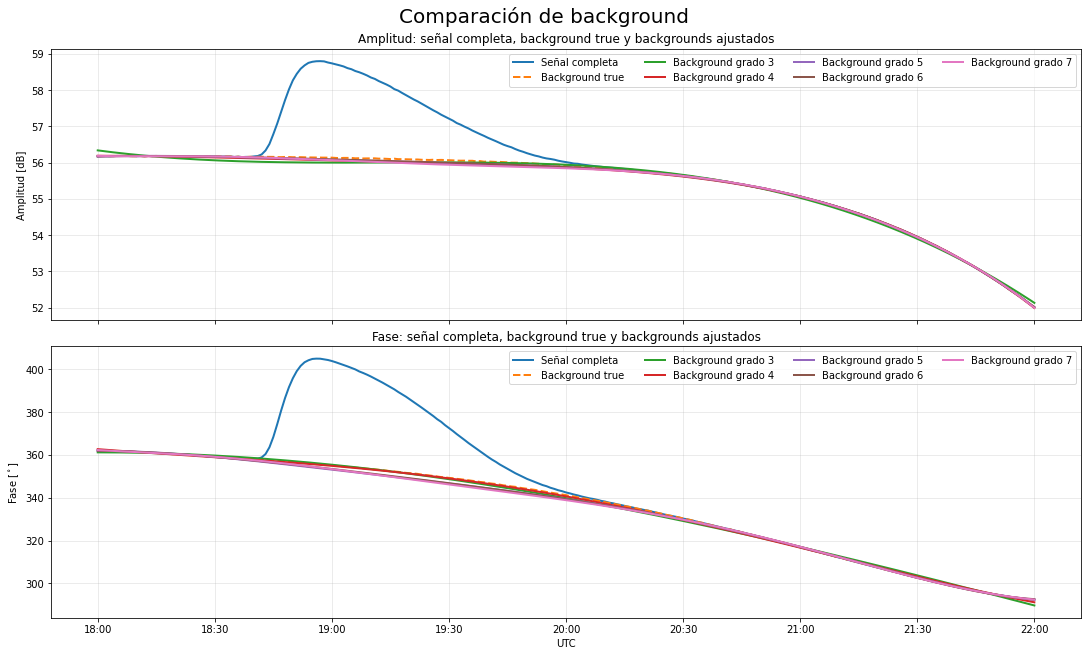

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, constrained_layout=True)

# ===== Arriba: amplitud =====
ax = axes[0]
ax.plot(time_utc, A_syn, label="Señal completa", linewidth=2)
ax.plot(time_utc, A_bg, label="Background true", linewidth=2, linestyle="--")
for deg in BG_DEGREES:
    ax.plot(time_utc, separated["A_syn"][deg]["background"], label=f"Background grado {deg}", linewidth=2)
ax.set_title("Amplitud: señal completa, background true y backgrounds ajustados")
ax.set_ylabel("Amplitud [dB]")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4)

# ===== Abajo: fase =====
ax = axes[1]
ax.plot(time_utc, phi_syn, label="Señal completa", linewidth=2)
ax.plot(time_utc, phi_bg, label="Background true", linewidth=2, linestyle="--")
for deg in BG_DEGREES:
    ax.plot(time_utc, separated["phi_syn"][deg]["background"], label=f"Background grado {deg}", linewidth=2)
ax.set_title("Fase: señal completa, background true y backgrounds ajustados")
ax.set_ylabel(r"Fase [$^\circ$]")
ax.set_xlabel("UTC")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4)

date_fmt = mdates.DateFormatter("%H:%M")
axes[1].xaxis.set_major_formatter(date_fmt)
fig.suptitle("Comparación de background", fontsize=20)
plt.show()

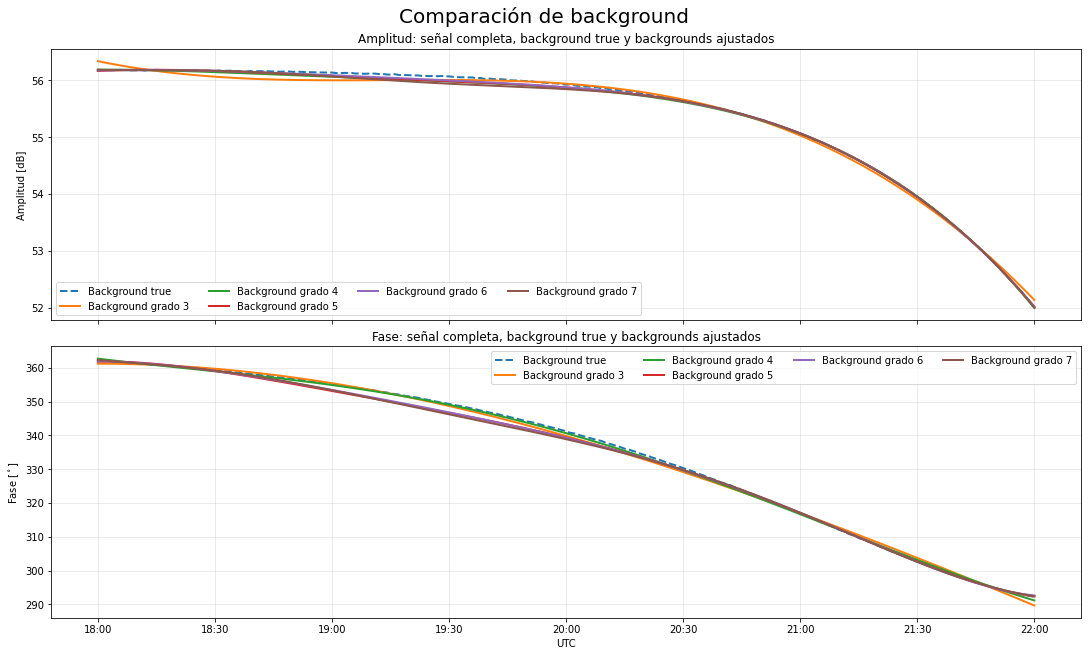

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, constrained_layout=True)

# ===== Arriba: amplitud =====
ax = axes[0]
#ax.plot(time_utc, A_syn, label="Señal completa", linewidth=2)
ax.plot(time_utc, A_bg, label="Background true", linewidth=2, linestyle="--")
for deg in BG_DEGREES:
    ax.plot(time_utc, separated["A_syn"][deg]["background"], label=f"Background grado {deg}", linewidth=2)
ax.set_title("Amplitud: señal completa, background true y backgrounds ajustados")
ax.set_ylabel("Amplitud [dB]")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4)

# ===== Abajo: fase =====
ax = axes[1]
#ax.plot(time_utc, phi_syn, label="Señal completa", linewidth=2)
ax.plot(time_utc, phi_bg, label="Background true", linewidth=2, linestyle="--")
for deg in BG_DEGREES:
    ax.plot(time_utc, separated["phi_syn"][deg]["background"], label=f"Background grado {deg}", linewidth=2)
ax.set_title("Fase: señal completa, background true y backgrounds ajustados")
ax.set_ylabel(r"Fase [$^\circ$]")
ax.set_xlabel("UTC")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4)

date_fmt = mdates.DateFormatter("%H:%M")
axes[1].xaxis.set_major_formatter(date_fmt)
fig.suptitle("Comparación de background", fontsize=20)
plt.show()

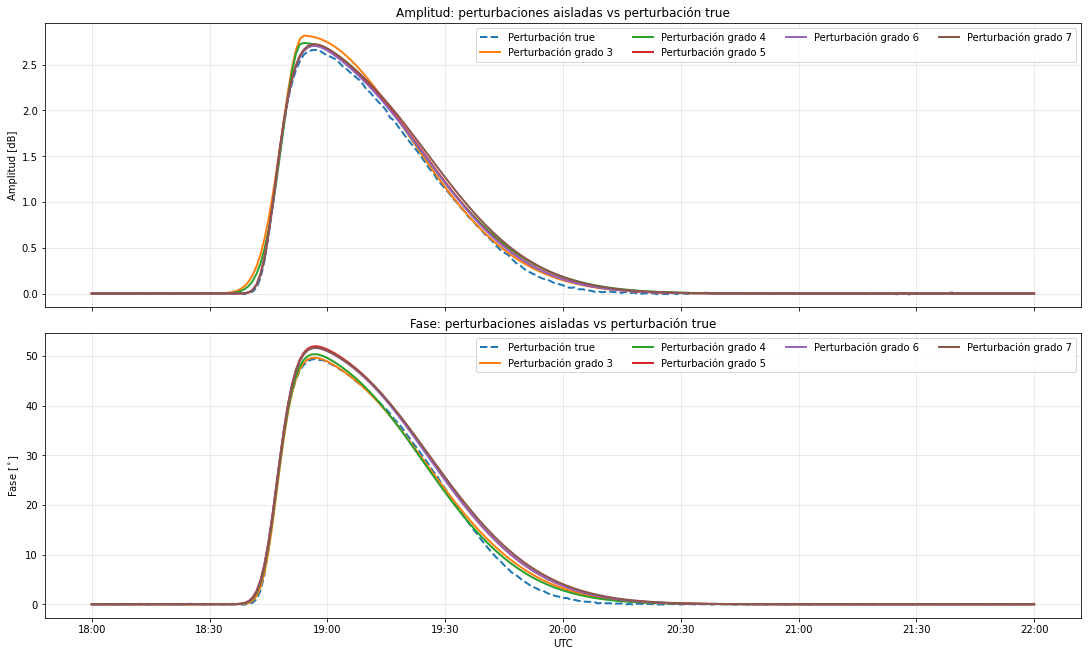

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, constrained_layout=True)

# ===== Arriba: perturbaciones de amplitud =====
ax = axes[0]
ax.plot(time_utc, A_pert_true, label="Perturbación true", linewidth=2, linestyle="--")
for deg in BG_DEGREES:
    ax.plot(time_utc, separated["A_syn"][deg]["perturbation"], label=f"Perturbación grado {deg}", linewidth=2)
ax.set_title("Amplitud: perturbaciones aisladas vs perturbación true")
ax.set_ylabel("Amplitud [dB]")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4)

# ===== Abajo: perturbaciones de fase =====
ax = axes[1]
ax.plot(time_utc, phi_pert_true, label="Perturbación true", linewidth=2, linestyle="--")
for deg in BG_DEGREES:
    ax.plot(time_utc, separated["phi_syn"][deg]["perturbation"], label=f"Perturbación grado {deg}", linewidth=2)
ax.set_title("Fase: perturbaciones aisladas vs perturbación true")
ax.set_ylabel(r"Fase [$^\circ$]")
ax.set_xlabel("UTC")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4)

date_fmt = mdates.DateFormatter("%H:%M")
axes[1].xaxis.set_major_formatter(date_fmt)
plt.show()

In [11]:
print("=== COMPARACIÓN CONTRA BACKGROUND / PERTURBACIÓN TRUE: AMPLITUD ===")
print(comparison_A.round(6).to_string(index=False))

print("\n=== COMPARACIÓN CONTRA BACKGROUND / PERTURBACIÓN TRUE: FASE ===")
print(comparison_phi.round(6).to_string(index=False))

best_bg_A = int(comparison_A.loc[comparison_A["rmse_bg"].idxmin(), "grado_bg"])
best_pert_A = int(comparison_A.loc[comparison_A["rmse_pert"].idxmin(), "grado_bg"])
best_bg_phi = int(comparison_phi.loc[comparison_phi["rmse_bg"].idxmin(), "grado_bg"])
best_pert_phi = int(comparison_phi.loc[comparison_phi["rmse_pert"].idxmin(), "grado_bg"])

print("\nGrados evaluados:", BG_DEGREES)
print("Mejor grado por RMSE de background (amplitud):", best_bg_A)
print("Mejor grado por RMSE de perturbación (amplitud):", best_pert_A)
print("Mejor grado por RMSE de background (fase):", best_bg_phi)
print("Mejor grado por RMSE de perturbación (fase):", best_pert_phi)

=== COMPARACIÓN CONTRA BACKGROUND / PERTURBACIÓN TRUE: AMPLITUD ===
   canal  grado_bg  rmse_bg   mae_bg   bias_bg    r2_bg  rmse_pert  mae_pert  bias_pert  r2_pert  rmse_total_vs_data  mae_total_vs_data
Amplitud         3 0.071895 0.056238 -0.032934 0.995403   0.063395  0.033908   0.032934 0.993903            0.053534           0.043549
Amplitud         4 0.047036 0.035966 -0.032750 0.998033   0.053557  0.034238   0.032750 0.995649            0.025230           0.016473
Amplitud         5 0.039693 0.028275 -0.025525 0.998599   0.040553  0.026543   0.025525 0.997505            0.009333           0.007456
Amplitud         6 0.033859 0.024406 -0.021807 0.998980   0.034856  0.022842   0.021807 0.998157            0.009139           0.007257
Amplitud         7 0.058023 0.037973 -0.035644 0.997006   0.058401  0.036636   0.035644 0.994826            0.007621           0.006040

=== COMPARACIÓN CONTRA BACKGROUND / PERTURBACIÓN TRUE: FASE ===
canal  grado_bg  rmse_bg   mae_bg   bias_bg    r2_b

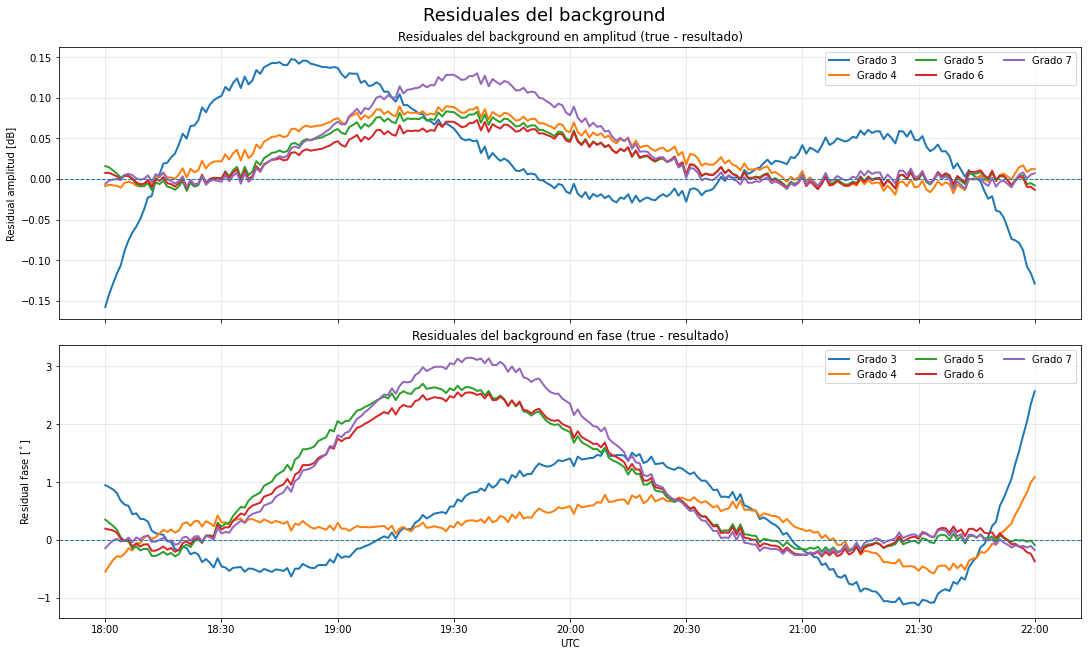

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, constrained_layout=True)

# ===== Arriba: residuales de background en amplitud =====
ax = axes[0]
for deg in BG_DEGREES:
    resid_A_bg = A_bg - separated["A_syn"][deg]["background"]
    ax.plot(time_utc, resid_A_bg, linewidth=2, label=f"Grado {deg}")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("Residuales del background en amplitud (true - resultado)")
ax.set_ylabel("Residual amplitud [dB]")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)

# ===== Abajo: residuales de background en fase =====
ax = axes[1]
for deg in BG_DEGREES:
    resid_phi_bg = phi_bg - separated["phi_syn"][deg]["background"]
    ax.plot(time_utc, resid_phi_bg, linewidth=2, label=f"Grado {deg}")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("Residuales del background en fase (true - resultado)")
ax.set_ylabel(r"Residual fase [$^\circ$]")
ax.set_xlabel("UTC")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle("Residuales del background", fontsize=18)
plt.show()

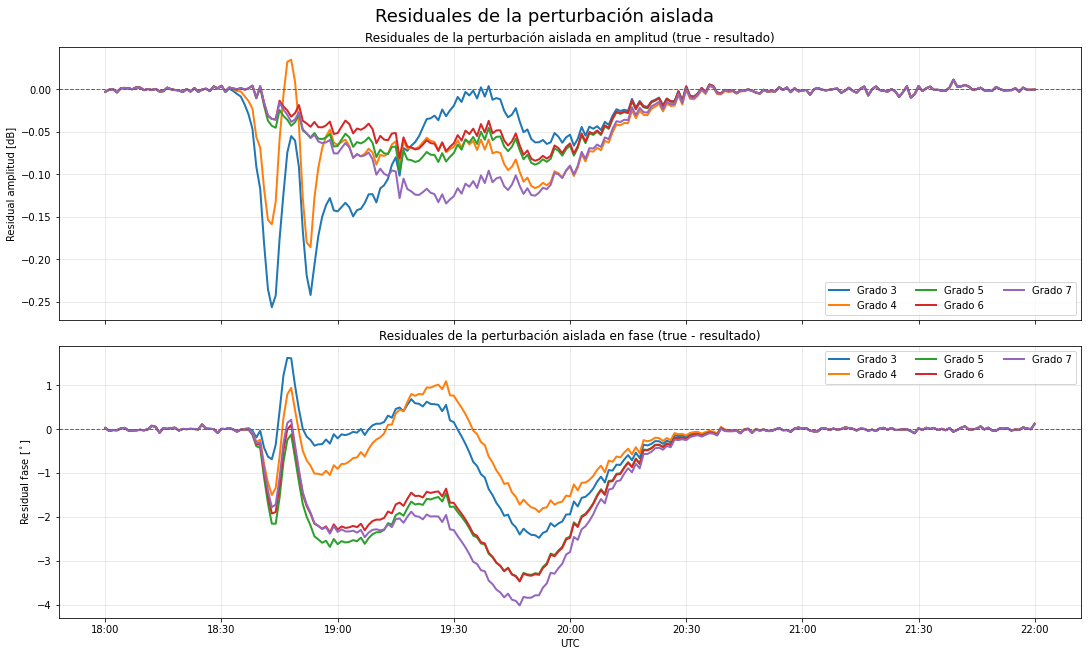

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, constrained_layout=True)

# ===== Arriba: residuales de perturbación en amplitud =====
ax = axes[0]
for deg in BG_DEGREES:
    resid_A_pert = A_pert_true - separated["A_syn"][deg]["perturbation"]
    ax.plot(time_utc, resid_A_pert, linewidth=2, label=f"Grado {deg}")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("Residuales de la perturbación aislada en amplitud (true - resultado)")
ax.set_ylabel("Residual amplitud [dB]")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)

# ===== Abajo: residuales de perturbación en fase =====
ax = axes[1]
for deg in BG_DEGREES:
    resid_phi_pert = phi_pert_true - separated["phi_syn"][deg]["perturbation"]
    ax.plot(time_utc, resid_phi_pert, linewidth=2, label=f"Grado {deg}")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title("Residuales de la perturbación aislada en fase (true - resultado)")
ax.set_ylabel(r"Residual fase [$^\circ$]")
ax.set_xlabel("UTC")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle("Residuales de la perturbación aislada", fontsize=18)
plt.show()

In [14]:
output_filename = "best_background_perturbation_separation.h5"

A_background_best   = np.asarray(separated["best_A"]["background"], dtype=float)
A_perturbation_best = np.asarray(separated["best_A"]["perturbation"], dtype=float)
phi_background_best = np.asarray(separated["best_phi"]["background"], dtype=float)
phi_perturbation_best = np.asarray(separated["best_phi"]["perturbation"], dtype=float)
timestamps_unix = np.asarray(timestamps, dtype=float)

n = len(timestamps_unix)
assert len(A_background_best) == n
assert len(A_perturbation_best) == n
assert len(phi_background_best) == n
assert len(phi_perturbation_best) == n

with h5py.File(output_filename, "w") as f:
    f.create_dataset("timestamps", data=timestamps_unix)
    f.create_dataset("A_background", data=A_background_best)
    f.create_dataset("A_perturbation", data=A_perturbation_best)
    f.create_dataset("phi_background", data=phi_background_best)
    f.create_dataset("phi_perturbation", data=phi_perturbation_best)

    # atributos útiles
    if "best_deg" in fit_A:
        f.attrs["best_degree_A"] = int(fit_A["best_deg"])
    if "best_deg" in fit_phi:
        f.attrs["best_degree_phi"] = int(fit_phi["best_deg"])
    f.attrs["description"] = (
        "Separación del mejor background y perturbación según el mejor AIC "
        "en amplitud y fase."
    )

print(f"Archivo guardado: {output_filename}")
print(f"  timestamps         : {timestamps_unix.shape}")
print(f"  A_background       : {A_background_best.shape}")
print(f"  A_perturbation     : {A_perturbation_best.shape}")
print(f"  phi_background     : {phi_background_best.shape}")
print(f"  phi_perturbation   : {phi_perturbation_best.shape}")
if "best_deg" in fit_A:
    print(f"  mejor grado A      : {fit_A['best_deg']}")
if "best_deg" in fit_phi:
    print(f"  mejor grado phi    : {fit_phi['best_deg']}")

Archivo guardado: best_background_perturbation_separation.h5
  timestamps         : (241,)
  A_background       : (241,)
  A_perturbation     : (241,)
  phi_background     : (241,)
  phi_perturbation   : (241,)
  mejor grado A      : 7
  mejor grado phi    : 7


In [15]:
output_filename = "best_background_perturbation_separation_rmsebg.h5"

# Mejor grado según RMSE del background true
best_deg_A = int(comparison_A.loc[comparison_A["rmse_bg"].idxmin(), "grado_bg"])
best_deg_phi = int(comparison_phi.loc[comparison_phi["rmse_bg"].idxmin(), "grado_bg"])

# Series separadas correspondientes a esos mejores grados
A_background_best = np.asarray(separated["A_syn"][best_deg_A]["background"], dtype=float)
A_perturbation_best = np.asarray(separated["A_syn"][best_deg_A]["perturbation"], dtype=float)

phi_background_best = np.asarray(separated["phi_syn"][best_deg_phi]["background"], dtype=float)
phi_perturbation_best = np.asarray(separated["phi_syn"][best_deg_phi]["perturbation"], dtype=float)

timestamps_unix = np.asarray(timestamps, dtype=float)

n = len(timestamps_unix)
assert len(A_background_best) == n
assert len(A_perturbation_best) == n
assert len(phi_background_best) == n
assert len(phi_perturbation_best) == n

with h5py.File(output_filename, "w") as f:
    f.create_dataset("timestamps", data=timestamps_unix)
    f.create_dataset("A_background", data=A_background_best)
    f.create_dataset("A_perturbation", data=A_perturbation_best)
    f.create_dataset("phi_background", data=phi_background_best)
    f.create_dataset("phi_perturbation", data=phi_perturbation_best)

    f.attrs["criterion"] = "best degree selected by minimum rmse_bg against true background"
    f.attrs["best_degree_A"] = best_deg_A
    f.attrs["best_degree_phi"] = best_deg_phi

print(f"Archivo guardado: {output_filename}")
print(f"mejor grado A   (rmse_bg): {best_deg_A}")
print(f"mejor grado phi (rmse_bg): {best_deg_phi}")
print(f"shapes: timestamps={timestamps_unix.shape}, "
      f"A_bg={A_background_best.shape}, A_pert={A_perturbation_best.shape}, "
      f"phi_bg={phi_background_best.shape}, phi_pert={phi_perturbation_best.shape}")

Archivo guardado: best_background_perturbation_separation_rmsebg.h5
mejor grado A   (rmse_bg): 6
mejor grado phi (rmse_bg): 4
shapes: timestamps=(241,), A_bg=(241,), A_pert=(241,), phi_bg=(241,), phi_pert=(241,)
